# Regime-Shift: Macro-Aware Tactical Asset Allocation Engine

Detects the market regime (**Bull / Bear / Crisis**) from a Hidden Markov Model
fit on Indian-market data, and dynamically reallocates a 3-asset portfolio
(equity / bonds / gold) to match — validated with **walk-forward testing**
so the model never gets to see the future while being scored.

Pipeline: `data → features → regime detection → walk-forward validation → optimization → backtest → results`

Needs real internet access to Yahoo Finance to run for real. See `README.md`
for the key decisions behind every choice made below, and each `test_*.py`
file for the offline (no-network) checks each module was verified against
during development.

In [1]:
import matplotlib.pyplot as plt

from data import load_market_data, PRICE_TICKERS
from features import build_feature_matrix, zscore_expanding
from regime import select_hmm_columns, fit_regime_model, label_states, transition_matrix_df
from validation import run_walk_forward_regimes
from backtest import compare_strategies
from main import plot_regime_overlay, plot_equity_curves

plt.rcParams["figure.figsize"] = (12, 5)

/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. Data

Pulls daily prices for **NIFTYBEES.NS** (equity), **LTGILTBEES.NS** (8-13yr
G-Sec long gilt, the bonds leg), **GOLDBEES.NS** (gold), plus **^INDIAVIX**
as a fear-gauge feature only — never held in the portfolio. `auto_adjust=True`
so dividends/splits don't inject fake price jumps. See the README for why
these specific tickers over the alternatives considered (Bharat Bond ETFs,
LIQUIDBEES).

In [2]:
master, prices = load_market_data(start="2016-01-01")
print(f"{len(master)} trading days, {master.index.min().date()} to {master.index.max().date()}")
master.head()

Clipping 4 of those single-day move(s) to +-25%.
1689 trading days, 2019-06-21 to 2026-07-24


,NIFTYBEES.NS,LTGILTBEES.NS,GOLDBEES.NS,VIX
Date,,,,
2019-06-21,-0.006552,-0.007722,0.000202,14.61
2019-06-24,-0.002218,0.001549,0.008098,15.22
2019-06-25,0.005398,0.000000,0.013571,15.01
2019-06-26,0.004656,-0.004137,-0.018901,14.75
2019-06-27,0.001315,0.002587,-0.002147,14.65


## 2. Feature Engineering

Momentum (4 windows: 5/21/63/126d) off price levels, realized volatility
(3 windows: 5/21/63d, annualized) off log returns, per asset — plus the raw
VIX level. Left un-scaled here on purpose: Section 3 below scales a specific
lean subset one way for a quick sanity-check fit, and Section 4 scales it a
*different*, stricter way for the real walk-forward result. See the README's
"Two different z-scoring schemes, on purpose" note for why.

In [3]:
feats = build_feature_matrix(master, prices)
equity_ticker = PRICE_TICKERS["equity"]
print(f"{feats.shape[1]} candidate features, {len(feats)} rows after lookback trim")
feats.head()

22 candidate features, 1563 rows after lookback trim


,NIFTYBEES.NS_mom_5d,NIFTYBEES.NS_mom_21d,NIFTYBEES.NS_mom_63d,NIFTYBEES.NS_mom_126d,LTGILTBEES.NS_mom_5d,LTGILTBEES.NS_mom_21d,LTGILTBEES.NS_mom_63d,LTGILTBEES.NS_mom_126d,GOLDBEES.NS_mom_5d,GOLDBEES.NS_mom_21d,...,NIFTYBEES.NS_vol_5d,NIFTYBEES.NS_vol_21d,NIFTYBEES.NS_vol_63d,LTGILTBEES.NS_vol_5d,LTGILTBEES.NS_vol_21d,LTGILTBEES.NS_vol_63d,GOLDBEES.NS_vol_5d,GOLDBEES.NS_vol_21d,GOLDBEES.NS_vol_63d,VIX
Date,,,,,,,,,,,,,,,,,,,,,
2019-12-30,8.993861,0.014438,0.061709,0.053202,0.004462,-0.000493,0.021169,0.047028,100.931650,0.028902,...,1.772477,1.257494,0.719331,0.026820,0.055560,0.041977,1.741055,1.256752,0.719690,11.01
2019-12-31,-0.006003,0.012838,0.064198,0.046546,0.003469,0.001979,0.019124,0.044892,0.023774,0.031020,...,0.109058,1.257624,0.719192,0.028598,0.054562,0.041927,0.025705,1.256790,0.719585,11.67
2020-01-02,0.005330,0.019634,0.060109,0.048890,0.005938,0.005938,0.022122,0.049020,0.017778,0.028181,...,0.115305,1.257750,0.718932,0.027719,0.054578,0.041901,0.041857,1.256788,0.719213,11.49
2020-01-03,0.007926,0.021660,0.062378,0.040569,0.007422,0.007921,0.026210,0.054922,0.041177,0.057206,...,0.107273,1.257651,0.718870,0.028039,0.054726,0.041597,0.192791,1.260690,0.721602,12.70
2020-01-06,-0.016903,-0.000777,0.047735,0.020454,0.000986,0.003460,0.017034,0.049096,0.058565,0.070905,...,0.159178,1.259273,0.719804,0.026479,0.055577,0.040424,0.205247,1.262152,0.722653,14.78


## 3. Regime Classifier — checkpoint fit

Fits a 3-state Gaussian HMM on a **lean, deliberately-chosen 3-feature
subset** (equity 21d vol, equity 21d momentum, India VIX — see README for
why not all ~20 Phase-2 candidates), scaled with one continuous **expanding**
z-score (safe in the sense that time `t`'s value never uses data from after
`t`, but still a single global fit).

**This fit is a checkpoint only — "does this even work" — not the version
the backtest uses.** It's fit once on the entire series, which means later
dates' labels were produced by a model that indirectly "knew" about the
whole dataset's distribution, including points still in its own future.
Section 4 redoes this properly.

In [4]:
raw_full = select_hmm_columns(feats, equity_ticker)
X_full = zscore_expanding(raw_full).dropna()

checkpoint_model = fit_regime_model(X_full)
_, checkpoint_map, checkpoint_labels = label_states(checkpoint_model, X_full)

print("Transition matrix (full-sample checkpoint fit):")
transition_matrix_df(checkpoint_model, checkpoint_map).round(3)

NOTE: zscore_expanding clipped 186 value(s) past +-8.0 std devs -- likely a bad tick or unadjusted split, not real signal.


/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_po

/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: divide by zero encountered in matmul
  stats['obs'] += posteriors.T @ X
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: overflow encountered in matmul
  stats['obs'] += posteriors.T @ X
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: invalid value encountered in matmul
  stats['obs'] += posteriors.T @ X
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/hmmlearn/_emissions.py:157: RuntimeWarning: divide by zero encountered in matmul
  stats['obs**2'] += posteriors.T @ X**2
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/hmmlearn/_emissions.py:157: RuntimeWarning: overflow encountered in matmul
  stats['obs**2'] += posteriors.T @ X**2
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/hmmlearn/_emissions.py:157: RuntimeWarning: invalid value enc

Transition matrix (full-sample checkpoint fit):


/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_po

,Bull,Bear,Crisis
Bull,0.987,0.013,0.000
Bear,0.016,0.972,0.011
Crisis,0.013,0.015,0.972


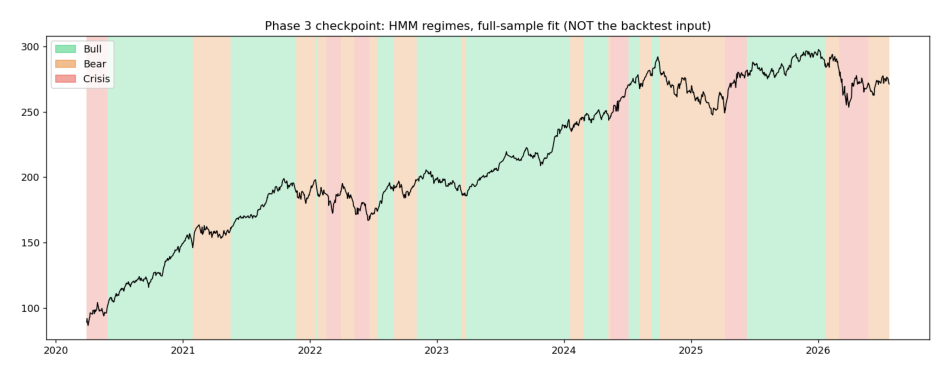

In [5]:
plot_regime_overlay(
    prices[equity_ticker], checkpoint_labels,
    "Phase 3 checkpoint: HMM regimes, full-sample fit (NOT the backtest input)",
    "regime_overlay_phase3_checkpoint.png",
)
plt.imshow(plt.imread("regime_overlay_phase3_checkpoint.png")); plt.axis("off"); plt.show()

## 4. Walk-Forward Validation

Refits the HMM **separately inside each training fold**, using only that
fold's own data to fit both the z-scoring stats and the HMM itself, then
predicts on the held-out test fold immediately after it. Concatenating every
fold's out-of-sample predictions gives one regime label per day that a live
system could actually have produced *at the time* — this is the series that
actually gets backtested, not Section 3's checkpoint.

`validation.py`'s `test_truncating_future_data_does_not_change_past_folds`
test is the direct empirical proof this holds: feeding the model extra
future data never changes any already-computed past fold's labels.

In [6]:
wf_labels, folds = run_walk_forward_regimes(feats, equity_ticker)
print(f"{len(folds)} folds, {len(wf_labels)} out-of-sample regime days")
wf_labels.value_counts()

/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/util

/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
Model is not converging.  Current: 148.63456307470153 is not greater than 148.63467533414772. Delta is -0.00011225944618331596


/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/util

/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/util

/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/util

...

/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: divide by zero encountered in matmul
  stats['obs'] += posteriors.T @ X
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: overflow encountered in matmul
  stats['obs'] += posteriors.T @ X
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: invalid value encountered in matmul
  stats['obs'] += posteriors.T @ X
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/hmmlearn/_emissions.py:157: RuntimeWarning: divide by zero encountered in matmul
  stats['obs**2'] += posteriors.T @ X**2
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/hmmlearn/_emissions.py:157: RuntimeWarning: overflow encountered in matmul
  stats['obs**2'] += posteriors.T @ X**2
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/hmmlearn/_emissions.py:157: RuntimeWarning: invalid value enc

/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_po

/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: divide by zero encountered in matmul
  stats['obs'] += posteriors.T @ X
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: overflow encountered in matmul
  stats['obs'] += posteriors.T @ X
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: invalid value encountered in matmul
  stats['obs'] += posteriors.T @ X
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/hmmlearn/_emissions.py:157: RuntimeWarning: divide by zero encountered in matmul
  stats['obs**2'] += posteriors.T @ X**2
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/hmmlearn/_emissions.py:157: RuntimeWarning: overflow encountered in matmul
  stats['obs**2'] += posteriors.T @ X**2
/Users/pranavnori/Desktop/.venv/lib/python3.9/site-packages/hmmlearn/_emissions.py:157: RuntimeWarning: invalid value enc

17 folds, 1059 out-of-sample regime days


Bull      1012
Bear        30
Crisis      17
Name: count, dtype: int64

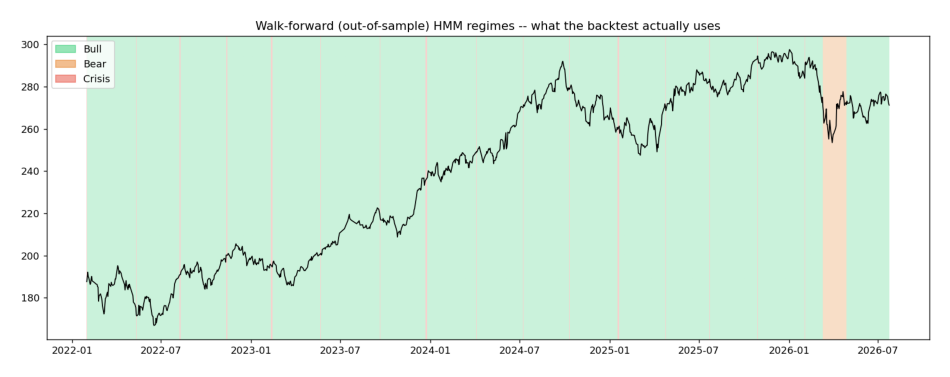

In [7]:
plot_regime_overlay(
    prices[equity_ticker], wf_labels,
    "Walk-forward (out-of-sample) HMM regimes -- what the backtest actually uses",
    "regime_overlay_walk_forward.png",
)
plt.imshow(plt.imread("regime_overlay_walk_forward.png")); plt.axis("off"); plt.show()

## 5. Portfolio Optimization + Backtest

Each regime maps to a convex objective (`portfolio.py`): Bull/Bear use
mean-variance utility with regime-dependent risk aversion, Crisis is pure
minimum-variance. Rebalances **on regime change**, not a fixed schedule, with
a 7.5bp transaction cost per rebalance (mid-point of the 5-10bp range in the
brief). Compared against static 60/40 and equal-weight benchmarks, both
rebalanced monthly with the same cost treatment for a fair comparison.

In [8]:
asset_cols = list(PRICE_TICKERS.values())
summary, results = compare_strategies(master[asset_cols], wf_labels, asset_cols)
summary.round(3)

,Ann. Return,Ann. Vol,Sharpe,Sortino,Max Drawdown,Calmar,Ann. Turnover
Regime-Shift (dynamic),0.198,0.169,1.173,1.546,-0.136,1.456,6.926
Static 60/40,0.101,0.136,0.740,0.839,-0.238,0.424,0.104
Equal-Weight,0.139,0.130,1.066,1.178,-0.153,0.907,0.150


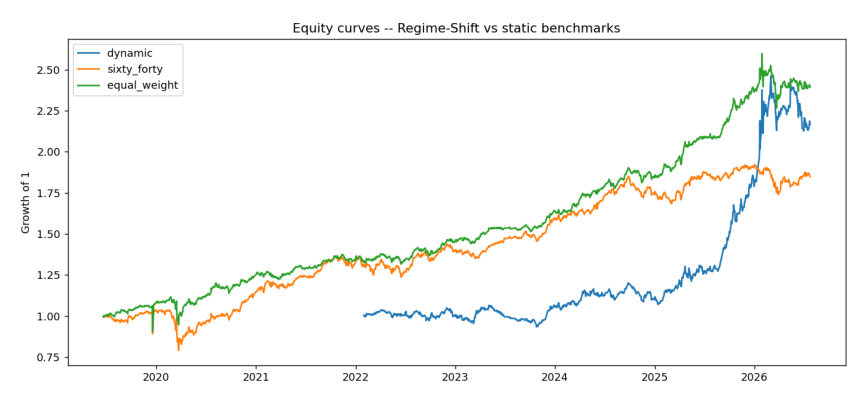

In [9]:
plot_equity_curves(results, "equity_curves.png")
plt.imshow(plt.imread("equity_curves.png")); plt.axis("off"); plt.show()

## Results

See `results_summary.csv` (saved below) for the same table `main.py`
produces end-to-end. Full reasoning behind every design choice above —
why these tickers, why 3 regimes, why these features, why best-of-10 HMM
restarts, why two different z-scoring schemes, why log returns for features
but simple returns for the portfolio math, why rebalance-on-regime-change —
is in `README.md`.

In [10]:
summary.round(4).to_csv("results_summary.csv")
print("Saved results_summary.csv")

Saved results_summary.csv
